In [5]:
import numpy as np # Para cálculos numéricos
import matplotlib.pyplot as plt # Para crear gráficas
import scipy.stats as sps # Para distribuciones discretas y continuas, pruebas estadísticas
from scipy.stats import geom, nbinom # Para distribuciones geométrica y binomial negativa

$\color{red}{\text{Ejercicio 2.}}$ Un examen de Estadística consta de 20 preguntas tipo test y se conoce de experiencias
anteriores que un alumno tiene probabilidad 0.7 de contestar bien cada pregunta. Obtener:

a) La probabilidad de que la primera pregunta que contesta bien sea la cuarta.


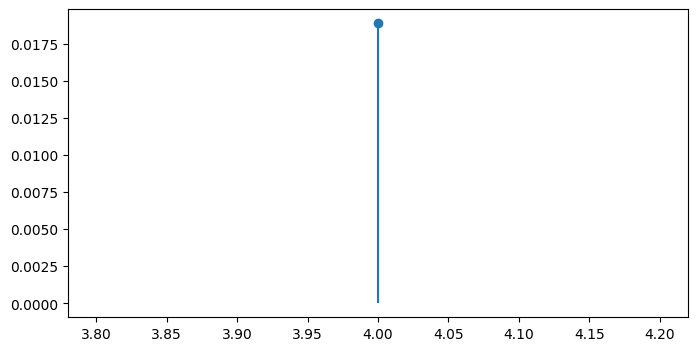

In [6]:
ej2a = geom.pmf(4,0.7)
plt.figure(figsize=(8,4))
plt.stem(4,ej2a,basefmt="")
plt.show()

In [7]:
print('a) La probabilidad de que el primer éxito ocurra en el cuarto intento es:', ej2a)

a) La probabilidad de que el primer éxito ocurra en el cuarto intento es: 0.018900000000000007


b) Sabiendo que para aprobar el examen es necesario contestar bien a 10 preguntas, ¿cuál es la probabilidad de que apruebe al contestar la pregunta duodécima?


In [8]:
ej2b = nbinom.pmf(2, 10, 0.7) 

print("b) La probabilidad de que el décimo éxito ocurra en el duodécimo intento es:", ej2b)

b) La probabilidad de que el décimo éxito ocurra en el duodécimo intento es: 0.13982524825499987


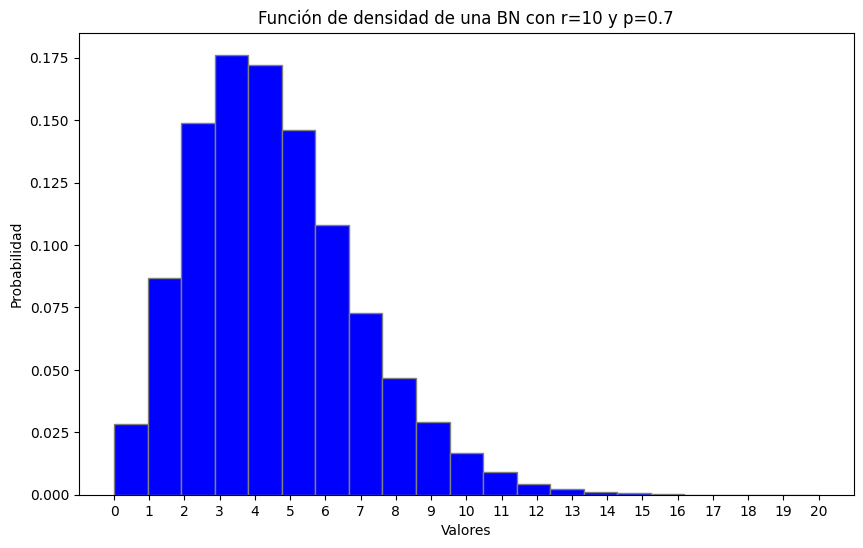

In [9]:
r = 10 # número de éxitos
p = 0.7 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla
#Vamos a generar numeros aleatorios que siguen una distribución geométrica
nbinom_numeros = sps.nbinom.rvs(r,p,size=s) 

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey" 
)
plt.xticks(np.arange(0, max(nbinom_numeros)+1, 1)) # Establecer los ticks del eje x
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=10 y p=0.7')
plt.show() #mostrar el gráfica

$\color{red}{\text{Ejercicio 3.}}$ Investigue sobre el problema de la caja de cerillos de Banach y explique su solución (sin simulación).


# Problema de Banach

El problema de la caja de cerillos de Banach nos dice lo siguiente:

Una persona tiene dos cajas de n cerillos, una en el bolsillo derecho y otra en el bolsillo izquierdo. Cuando necesita un cerillo escoge una caja al azar hasta que se encuentra una caja vacía. ¿Cuál es la probabilidad de que la otra caja tenga k cerillos?

Para la solución del problema consideramos que seguimos una Variable Aleatoria Binomial Negativa, donde al sacar una caja de cerillos, la probabilidad de que sea del bolsilo izquierdo o derecho es la misma, es decir

$$ p = \frac{1}{2}$$

Supongamos que tenemos lo caja 1 y la caja 2, ambos con n cerillos

Definimos el éxito E elegir la caja quedará vacía.

Buscamos la probabilidad de que al momento de elegir una caja y que esté vacía, la otra contenga $k$ cerillos.

Si en la caja hay $K$ cerillos es porque ya se retiraron $n - k$ y de la caja vacía se retiraron lo $n$ cerillos. Así que en total se han elegido $2n - k$ cerillos en total. Luego, en el momento en que uno se da cuenta que la caja está vacía es en el intento $2n - k + 1$, en dicho intento se elige la caja vacía (por eso nos damos cuenta que no tiene cerillos).

Aquí hemos elegido $n$ veces la caja vacía, esto sucede con probabilidad $(\frac{1}{2})^{n}$. Además, se ha elegido $n - K$ veces la otra caja, lo cual ocurre con probabilidad $(\frac{1}{2})^{n-k}$. Así la probabilidad de un evento específico es de $(\frac{1}{2})^{n}\cdot(\frac{1}{2})^{n-k} = (\frac{1}{2})^{2n-k}$.

Notemos que tenemos una vez que se ha elegido el orden en el que se tomaron lo $n$ cerillos de la qcaja que quedó vacía, los $n - k$ restantes se sabe que se formaron de la caja que aún tiene cerillos. Así, hoy $\binom{2n-k}{n}$ maneras de elegir en qué orden se tomaron los $n$ cerillos de la caja que quedó vacía. Luego, la probabilidad hasta el intento $2n - k$ es de $$\binom{2n-k}{n} \left(\frac{1}{2}\right)^{2n-k}$$.

Finalmente, en la extracción del cerillo $2n - k + 1$ se elige la caja vacía, y esto sucede con la probabilidad $\left(\frac{1}{2}\right)$. Así la probabilidad es de $$\binom{2n-k}{n} \left(\frac{1}{2}\right)^{2n-k} \cdot \left(\frac{1}{2}\right)$$.

Pero podemos considerar 2 casos, uno en el que la caja vacía es la 1, y otro deonde la caja vacía es la 2. Luego, la probabilidad 1 debe multiplicarse por 2 i.e., la probabilidad buscada es $$\left[\binom{2n-k}{n} \left(\frac{1}{2}\right)^{2n-k} \cdot \left(\frac{1}{2}\right) \right]$$

i.e., la probabilidad final es $$\binom{2n-k}{n} \left(\frac{1}{2}\right)^{2n-k}$$


$\color{red}{\text{Ejercicio 5.}}$ Una compañía petrolera realiza un estudio geológico que indica que un pozo petrolero exploratorio debería tener un 20% de posibilidades de encontrar petróleo.

- ¿Cuál es la probabilidad de que el primer pozo se produzca en el tercer pozo perforado?


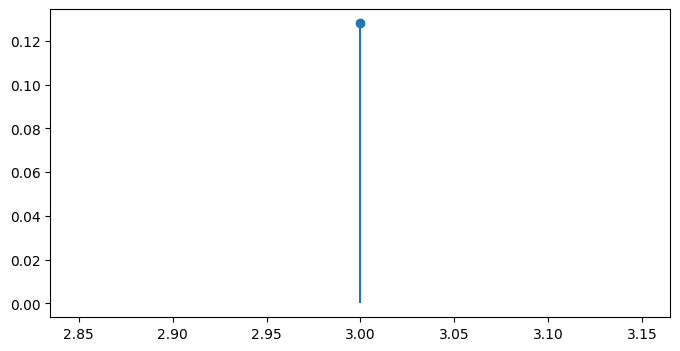

In [10]:
ej5a = geom.pmf(3,0.2)

plt.figure(figsize=(8,4))
plt.stem(3,ej5a,basefmt="")
plt.show()

In [11]:
print('La probabilidad de que el primer pozo sea el tercero:',ej5a)

La probabilidad de que el primer pozo sea el tercero: 0.12800000000000003


- ¿Cuál es la probabilidad de que el tercer pozo se produzca en el séptimo pozo perforado?


In [12]:
ej5b = nbinom.pmf(4, 3, 0.2)

print("La probabilidad de que el tercer pozo sea el séptimo:",ej5b)

La probabilidad de que el tercer pozo sea el séptimo: 0.04915200000000004


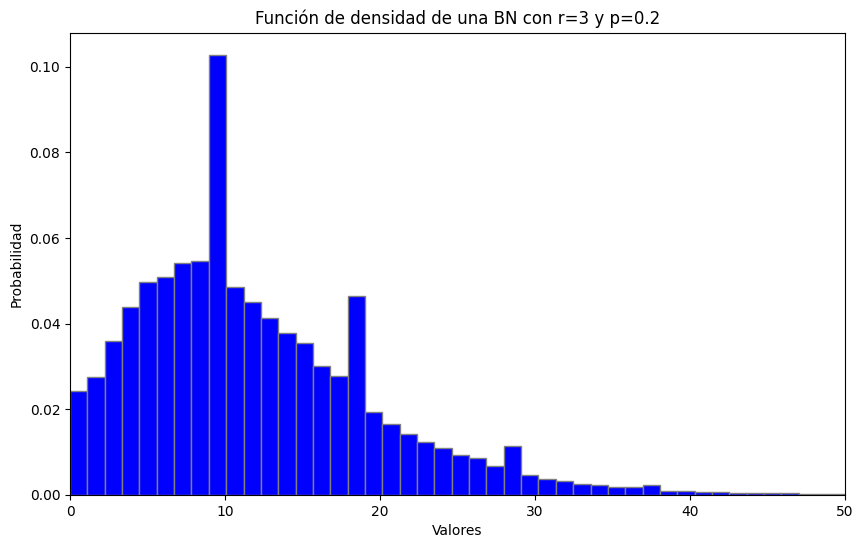

In [13]:
r = 3 # número de éxitos
p = 0.2 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla
#Vamos a generar numeros aleatorios que siguen una distribución geométrica
nbinom_numeros = sps.nbinom.rvs(r,p,size=s) 

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey" 
)
# Establecer los ticks del eje x
plt.xlim(0,50)
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=3 y p=0.2')
plt.show() #mostrar el gráfica

- ¿Cuál es la media y la varianza del número de pozos que se deben perforar si la compañía petrolera quiere establecer tres pozos productores?


In [14]:
media = sps.nbinom.mean(r,p)
varianza = sps.nbinom.var(r,p)

print("Media y varianza:")
print(f"Media: {media}")
print(f"Varianza: {varianza}")

Media y varianza:
Media: 12.000000000000002
Varianza: 60.0
